In [1]:
import pandas as pd
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

X_train = pd.read_csv("../data/processed/X_train.csv")
X_test = pd.read_csv("../data/processed/X_test.csv")
X_train_lr = pd.read_csv("../data/processed/X_train_lr.csv")
X_test_lr = pd.read_csv("../data/processed/X_test_lr.csv")
y_train = pd.read_csv("../data/processed/y_train.csv").squeeze()
y_test = pd.read_csv("../data/processed/y_test.csv").squeeze()

In [2]:
from sklearn.linear_model import LogisticRegression

model_lr = LogisticRegression(random_state=42, max_iter=1000, class_weight="balanced")
model_lr.fit(X_train_lr, y_train)
y_pred_lr = model_lr.predict(X_test_lr)

print("--- Baseline : Régression logistique ---")
print(classification_report(y_test, y_pred_lr, target_names=["Reste", "Part"]))

--- Baseline : Régression logistique ---
              precision    recall  f1-score   support

       Reste       0.92      0.76      0.83      1593
        Part       0.44      0.74      0.55       407

    accuracy                           0.76      2000
   macro avg       0.68      0.75      0.69      2000
weighted avg       0.82      0.76      0.77      2000



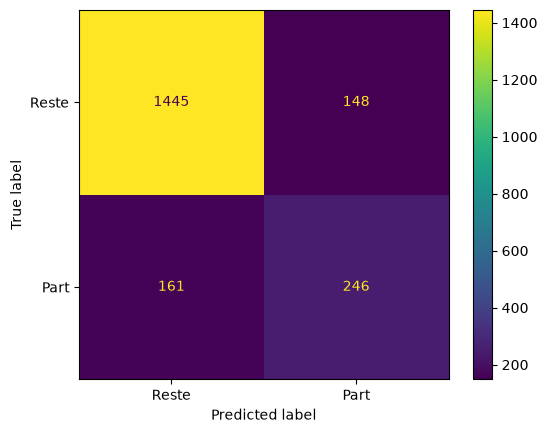

--- Random Forest ---
              precision    recall  f1-score   support

       Reste       0.90      0.91      0.90      1593
        Part       0.62      0.60      0.61       407

    accuracy                           0.85      2000
   macro avg       0.76      0.76      0.76      2000
weighted avg       0.84      0.85      0.84      2000



In [3]:
from sklearn.ensemble import RandomForestClassifier

model_rf = RandomForestClassifier(random_state=42, class_weight="balanced")
model_rf.fit(X_train, y_train)
y_pred_rf = model_rf.predict(X_test)

cm_rf = confusion_matrix(y_test, y_pred_rf)
ConfusionMatrixDisplay(cm_rf, display_labels=["Reste", "Part"]).plot()
plt.show()

print("--- Random Forest ---")
print(classification_report(y_test, y_pred_rf, target_names=["Reste", "Part"]))

In [4]:
# Probabilités au lieu de prédictions directes
y_proba_rf = model_rf.predict_proba(X_test)[:, 1]

# Test avec un seuil plus bas pour favoriser le rappel
seuil = 0.3
y_pred_rf_ajuste = (y_proba_rf >= seuil).astype(int)

print(f"--- Random Forest, seuil = {seuil} ---")
print(classification_report(y_test, y_pred_rf_ajuste, target_names=["Reste", "Part"]))

--- Random Forest, seuil = 0.3 ---
              precision    recall  f1-score   support

       Reste       0.93      0.72      0.81      1593
        Part       0.42      0.78      0.54       407

    accuracy                           0.73      2000
   macro avg       0.67      0.75      0.68      2000
weighted avg       0.82      0.73      0.76      2000



In [5]:
# Probabilités au lieu de prédictions directes
y_proba_rf = model_rf.predict_proba(X_test)[:, 1]

# Test avec un seuil plus bas pour favoriser le rappel
seuil = 0.2
y_pred_rf_ajuste = (y_proba_rf >= seuil).astype(int)

print(f"--- Random Forest, seuil = {seuil} ---")
print(classification_report(y_test, y_pred_rf_ajuste, target_names=["Reste", "Part"]))

--- Random Forest, seuil = 0.2 ---
              precision    recall  f1-score   support

       Reste       0.95      0.59      0.73      1593
        Part       0.35      0.87      0.50       407

    accuracy                           0.65      2000
   macro avg       0.65      0.73      0.62      2000
weighted avg       0.83      0.65      0.68      2000



In [6]:
seuil = 0.25
y_pred_rf_025 = (y_proba_rf >= seuil).astype(int)
print(classification_report(y_test, y_pred_rf_025, target_names=["Reste", "Part"]))

              precision    recall  f1-score   support

       Reste       0.94      0.66      0.77      1593
        Part       0.38      0.83      0.52       407

    accuracy                           0.69      2000
   macro avg       0.66      0.74      0.65      2000
weighted avg       0.82      0.69      0.72      2000



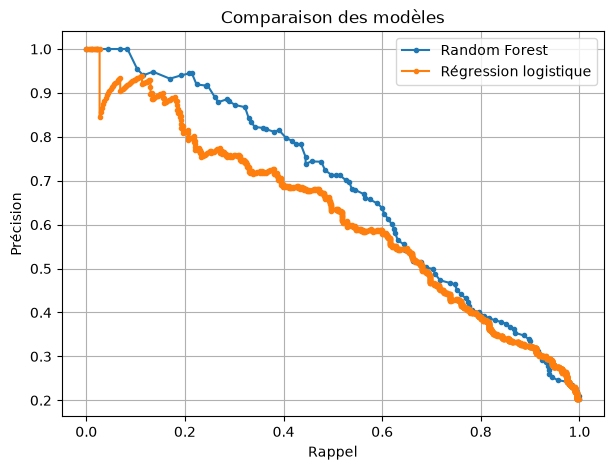

In [8]:
from sklearn.metrics import precision_recall_curve

precisions, recalls, _ = precision_recall_curve(y_test, y_proba_rf)

y_proba_lr = model_lr.predict_proba(X_test_lr)[:, 1]
precisions_lr, recalls_lr, _ = precision_recall_curve(y_test, y_proba_lr)

plt.figure(figsize=(7,5))
plt.plot(recalls, precisions, marker=".", label="Random Forest")
plt.plot(recalls_lr, precisions_lr, marker=".", label="Régression logistique")
plt.xlabel("Rappel")
plt.ylabel("Précision")
plt.title("Comparaison des modèles")
plt.legend()
plt.grid(True)
plt.show()

In [9]:
from sklearn.metrics import average_precision_score

pr_auc_rf = average_precision_score(y_test, y_proba_rf)
pr_auc_lr = average_precision_score(y_test, y_proba_lr)

print(f"PR-AUC Random Forest : {pr_auc_rf:.3f}")
print(f"PR-AUC Régression logistique : {pr_auc_lr:.3f}")

PR-AUC Random Forest : 0.671
PR-AUC Régression logistique : 0.618


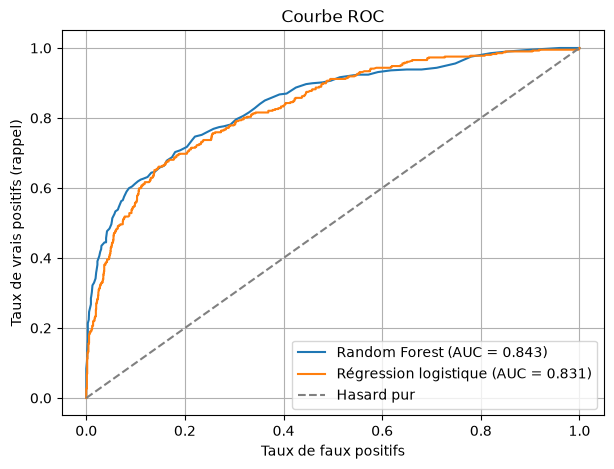

In [10]:
from sklearn.metrics import roc_curve, roc_auc_score

fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba_rf)
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_proba_lr)

auc_rf = roc_auc_score(y_test, y_proba_rf)
auc_lr = roc_auc_score(y_test, y_proba_lr)

plt.figure(figsize=(7,5))
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {auc_rf:.3f})")
plt.plot(fpr_lr, tpr_lr, label=f"Régression logistique (AUC = {auc_lr:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Hasard pur")
plt.xlabel("Taux de faux positifs")
plt.ylabel("Taux de vrais positifs (rappel)")
plt.title("Courbe ROC")
plt.legend()
plt.grid(True)
plt.show()

/home/angislad/Documents/the scientist/churn-prediction/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


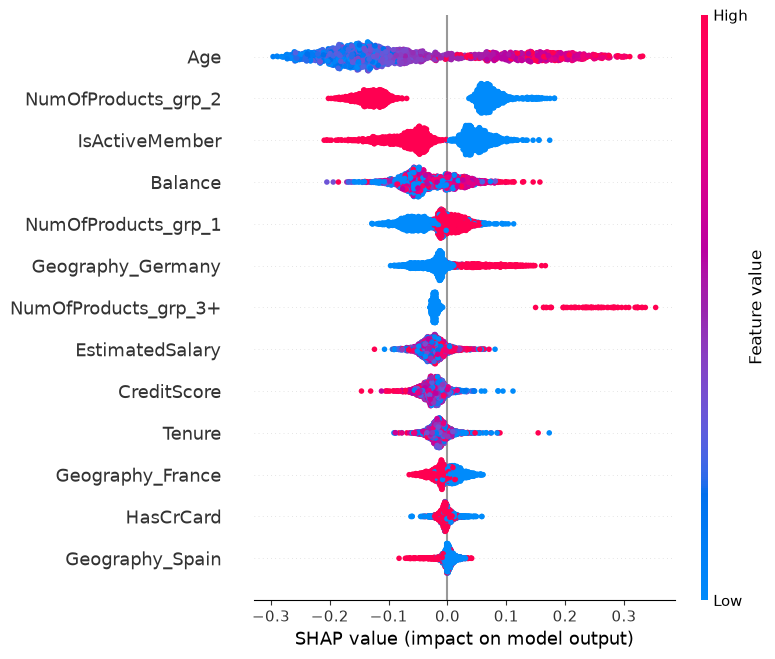

In [11]:
import shap

explainer = shap.TreeExplainer(model_rf)
shap_values = explainer.shap_values(X_test)

# Pour un problème de classification binaire, shap_values a 2 dimensions (classe 0 et classe 1)
# On s'intéresse à la classe 1 ("Part")
shap.summary_plot(shap_values[:, :, 1], X_test)

In [13]:
import joblib
import os

os.makedirs("../models", exist_ok=True)

joblib.dump(model_rf, "../models/random_forest.pkl")

['../models/random_forest.pkl']